# HAM10000 Skin Cancer Classification
## ConvNeXt-Base + Swin-Base + Channel/Spatial Attention (Paper-Style Pipeline)

Pipeline:
Input -> ConvNeXt and Swin branches -> feature fusion (2048) -> channel+spatial attention -> classifier -> output class


In [1]:
# If running on Colab, mount Drive to reuse the same HAM10000 structure as your existing notebook.\n
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

import os
import copy
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.io import read_image
from torchvision.models import (
    convnext_base, convnext_tiny,
    ConvNeXt_Base_Weights, ConvNeXt_Tiny_Weights,
    swin_b, swin_t,
    Swin_B_Weights, Swin_T_Weights,
 )

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('IN_COLAB =', IN_COLAB)
print('Device =', device)

Mounted at /content/drive
IN_COLAB = True
Device = cuda


In [2]:
# Paths follow your current notebook convention.
base_dir = '/content/drive/MyDrive/HAM10000'
split_dir = os.path.join(base_dir, 'splits')
raw_dir = os.path.join(base_dir, 'raw')
part1_dir = os.path.join(raw_dir, 'HAM10000_images_part_1')
part2_dir = os.path.join(raw_dir, 'HAM10000_images_part_2')

train_df = pd.read_csv(os.path.join(split_dir, 'train_split.csv'))
val_df = pd.read_csv(os.path.join(split_dir, 'val_split.csv'))
test_df = pd.read_csv(os.path.join(split_dir, 'test_split.csv'))

ckpt_dir = '/content/drive/MyDrive/DA_checkpoints/ConvNeXt_Swin_Attention'
os.makedirs(ckpt_dir, exist_ok=True)

class_names_path = os.path.join(base_dir, 'class_names.npy')
if os.path.exists(class_names_path):
    class_names = np.load(class_names_path, allow_pickle=True).tolist()
else:
    class_names = sorted(train_df['dx'].unique().tolist())

image_col = 'image_id'
label_col = 'dx'

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print('Classes:', class_names)

Train: 7010 | Val: 1502 | Test: 1503
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [3]:
# Resolve full image paths and encode labels.
def find_image_path(img_name):
    if not str(img_name).lower().endswith('.jpg'):
        img_name = f'{img_name}.jpg'
    p1 = os.path.join(part1_dir, img_name)
    p2 = os.path.join(part2_dir, img_name)
    if os.path.exists(p1):
        return p1
    if os.path.exists(p2):
        return p2
    return None

for df in [train_df, val_df, test_df]:
    df[image_col] = df[image_col].astype(str)
    df['full_path'] = df[image_col].apply(find_image_path)

for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    missing = df['full_path'].isna().sum()
    print(f'{name} missing images: {missing}')

label_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_label = {i: c for c, i in label_to_idx.items()}

train_df = train_df.dropna(subset=['full_path']).copy()
val_df = val_df.dropna(subset=['full_path']).copy()
test_df = test_df.dropna(subset=['full_path']).copy()

train_df['label_idx'] = train_df[label_col].map(label_to_idx)
val_df['label_idx'] = val_df[label_col].map(label_to_idx)
test_df['label_idx'] = test_df[label_col].map(label_to_idx)

print(train_df[['full_path', label_col, 'label_idx']].head())

train missing images: 0
val missing images: 0
test missing images: 0
                                           full_path   dx  label_idx
0  /content/drive/MyDrive/HAM10000/raw/HAM10000_i...   nv          5
1  /content/drive/MyDrive/HAM10000/raw/HAM10000_i...  mel          4
2  /content/drive/MyDrive/HAM10000/raw/HAM10000_i...   nv          5
3  /content/drive/MyDrive/HAM10000/raw/HAM10000_i...   nv          5
4  /content/drive/MyDrive/HAM10000/raw/HAM10000_i...  mel          4


Effective-number class weights: [0.94425726 0.6045805  0.28882083 2.6499348  0.285254   0.05707496
 2.1700778 ]


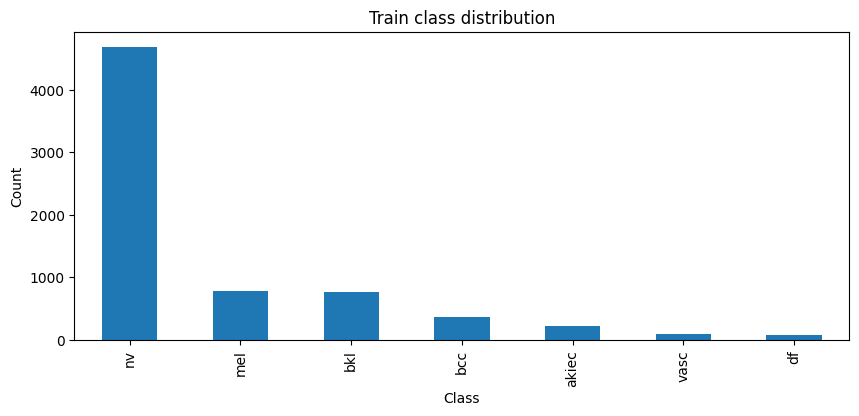

In [4]:
# Class weighting with Effective Number of Samples (Cui et al.)
# W_i = (1 - beta) / (1 - beta^n_i)
BETA = 0.9999

counts = train_df['label_idx'].value_counts().sort_index()
effective_num = 1.0 - np.power(BETA, counts.values.astype(np.float64))
class_weights_en = (1.0 - BETA) / np.clip(effective_num, a_min=1e-12, a_max=None)

# Normalize weights so mean weight = 1 (keeps loss scale stable).
class_weights_en = class_weights_en / np.mean(class_weights_en)
class_weights_en = class_weights_en.astype(np.float32)

class_weights_torch = torch.tensor(class_weights_en, dtype=torch.float32, device=device)
print('Effective-number class weights:', class_weights_en)

plt.figure(figsize=(10, 4))
train_df[label_col].value_counts().plot(kind='bar')
plt.title('Train class distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [5]:
# Data transforms: 224x224 + normalize, with augmentation for train only.
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 2

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=25),
    transforms.RandomResizedCrop((IMG_SIZE, IMG_SIZE), scale=(0.85, 1.0)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

class HAMDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = read_image(row['full_path']).float() / 255.0
        label = int(row['label_idx'])
        if self.transform is not None:
            img = self.transform((img * 255).byte())
        return img, label

train_ds = HAMDataset(train_df, transform=train_transform)
val_ds = HAMDataset(val_df, transform=eval_transform)
test_ds = HAMDataset(test_df, transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print('Dataloader ready.')

Dataloader ready.


In [6]:
# Model: ConvNeXt branch + Swin branch -> concat feature maps ->
# Channel attention + Spatial attention -> global pooling -> classifier

# Choose model size: 'full', 'balanced', 'lite'
MODEL_VARIANT = 'lite'
PROJ_DIM_PER_BRANCH = 512  # project each branch before fusion; None to disable

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(channels, hidden, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.mlp(w).view(b, c, 1, 1)
        return x * w

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_map = torch.mean(x, dim=1, keepdim=True)
        max_map, _ = torch.max(x, dim=1, keepdim=True)
        attn = torch.cat([avg_map, max_map], dim=1)
        attn = self.sigmoid(self.conv(attn))
        return x * attn

class HybridConvNeXtSwinAttention(nn.Module):
    def __init__(self, num_classes, variant='lite', proj_dim_per_branch=512):
        super().__init__()
        self.variant = variant
        self.proj_dim_per_branch = proj_dim_per_branch

        try:
            if variant == 'full':
                self.convnext = convnext_base(weights=ConvNeXt_Base_Weights.DEFAULT)
                self.swin = swin_b(weights=Swin_B_Weights.DEFAULT)
                conv_ch, swin_ch = 1024, 1024
            elif variant == 'balanced':
                self.convnext = convnext_base(weights=ConvNeXt_Base_Weights.DEFAULT)
                self.swin = swin_t(weights=Swin_T_Weights.DEFAULT)
                conv_ch, swin_ch = 1024, 768
            else:  # lite
                self.convnext = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
                self.swin = swin_t(weights=Swin_T_Weights.DEFAULT)
                conv_ch, swin_ch = 768, 768
        except Exception as e:
            print('Warning: pretrained weights unavailable, using random init.', e)
            if variant == 'full':
                self.convnext = convnext_base(weights=None)
                self.swin = swin_b(weights=None)
                conv_ch, swin_ch = 1024, 1024
            elif variant == 'balanced':
                self.convnext = convnext_base(weights=None)
                self.swin = swin_t(weights=None)
                conv_ch, swin_ch = 1024, 768
            else:
                self.convnext = convnext_tiny(weights=None)
                self.swin = swin_t(weights=None)
                conv_ch, swin_ch = 768, 768

        self.convnext_features = self.convnext.features
        self.swin_features = self.swin.features

        if proj_dim_per_branch is not None:
            self.conv_proj = nn.Sequential(
                nn.Conv2d(conv_ch, proj_dim_per_branch, kernel_size=1, bias=False),
                nn.BatchNorm2d(proj_dim_per_branch),
                nn.ReLU(inplace=True)
            )
            self.swin_proj = nn.Sequential(
                nn.Conv2d(swin_ch, proj_dim_per_branch, kernel_size=1, bias=False),
                nn.BatchNorm2d(proj_dim_per_branch),
                nn.ReLU(inplace=True)
            )
            fused_ch = 2 * proj_dim_per_branch
        else:
            self.conv_proj = nn.Identity()
            self.swin_proj = nn.Identity()
            fused_ch = conv_ch + swin_ch

        self.fused_ch = fused_ch
        self.channel_attn = ChannelAttention(channels=fused_ch, reduction=16)
        self.spatial_attn = SpatialAttention(kernel_size=7)

        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(fused_ch, num_classes)

    def extract_feature_vector(self, x):
        c_map = self.convnext_features(x)
        s_map = self.swin_features(x)
        s_map = self.swin.norm(s_map)
        s_map = s_map.permute(0, 3, 1, 2)

        c_map = self.conv_proj(c_map)
        s_map = self.swin_proj(s_map)

        fused_map = torch.cat([c_map, s_map], dim=1)
        fused_map = self.channel_attn(fused_map)
        fused_map = self.spatial_attn(fused_map)

        fused_vec = nn.functional.adaptive_avg_pool2d(fused_map, 1).flatten(1)
        return fused_vec

    def forward(self, x):
        feat = self.extract_feature_vector(x)
        out = self.classifier(self.dropout(feat))
        return out

In [16]:
# Training and evaluation utilities
import sys # Import sys for console output

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds, all_targets = [], []

    num_batches = len(loader) # Get total number of batches
    # Only print progress if there's more than one batch
    print_interval = max(1, num_batches // 10) if num_batches > 0 else 1

    for batch_idx, (images, labels) in enumerate(loader): # Enumerate to get batch index
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(labels.detach().cpu().numpy().tolist())

        # Simple console progress update
        if num_batches > 0 and ((batch_idx + 1) % print_interval == 0 or (batch_idx + 1) == num_batches):
            progress_percent = (batch_idx + 1) / num_batches * 100
            sys.stdout.write(f'\rBatch {batch_idx + 1}/{num_batches} [{progress_percent:.1f}%]')
            sys.stdout.flush()

    if num_batches > 0: # Clear the progress line only if there was progress to show
        sys.stdout.write('\r' + ' ' * 60 + '\r') # Clear the progress line after epoch
        sys.stdout.flush()

    avg_loss = total_loss / len(loader.dataset) # Correctly use loader.dataset
    acc = accuracy_score(all_targets, all_preds)
    return avg_loss, acc

num_classes = len(class_names)
model = HybridConvNeXtSwinAttention(
    num_classes=num_classes,
    variant=MODEL_VARIANT,
    proj_dim_per_branch=PROJ_DIM_PER_BRANCH
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model variant: {MODEL_VARIANT}')
print(f'Proj dim/branch: {PROJ_DIM_PER_BRANCH}')
print(f'Fused feature dim: {model.fused_ch}')
print(f'Total params: {total_params:,}')
print(f'Trainable params: {trainable_params:,}')
print(f'Approx model size (FP32): {total_params * 4 / (1024**2):.2f} MB')

criterion = nn.CrossEntropyLoss(weight=class_weights_torch)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)

Model variant: lite
Proj dim/branch: 512
Fused feature dim: 1024
Total params: 57,804,307
Trainable params: 57,804,307
Approx model size (FP32): 220.51 MB


In [12]:
EPOCHS = 10
best_val_acc = 0.0
best_state = copy.deepcopy(model.state_dict())
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

from tqdm.auto import tqdm

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    train_loss, train_acc = run_epoch(model, tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS} [Train]'), criterion, optimizer=optimizer)
    val_loss, val_acc = run_epoch(model, tqdm(val_loader, desc=f'Epoch {epoch}/{EPOCHS} [Val]'), criterion, optimizer=None)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - start
    print(f'Epoch {epoch:02d}/{EPOCHS} | time {elapsed:.1f}s | train_loss {train_loss:.4f} | train_acc {train_acc:.4f} | val_loss {val_loss:.4f} | val_acc {val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, os.path.join(ckpt_dir, 'best_model_convnext_swin.pth'))
        print(f"🔥 New best model found (Val Acc: {val_acc:.3f})")

model.load_state_dict(best_state)
print('Best val acc:', best_val_acc)

Epoch 1/10 [Train]:   0%|          | 0/439 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch 01/10 | time 471.8s | train_loss 1.7744 | train_acc 0.5558 | val_loss 1.4152 | val_acc 0.6378
🔥 New best model found (Val Acc: 0.638)


Epoch 2/10 [Train]:   0%|          | 0/439 [00:00<?, ?it/s]

Epoch 2/10 [Val]:   0%|          | 0/94 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch 09/10 | time 303.5s | train_loss 0.5374 | train_acc 0.8076 | val_loss 0.5848 | val_acc 0.8262
🔥 New best model found (Val Acc: 0.826)


Epoch 10/10 [Train]:   0%|          | 0/439 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch 10/10 | time 262.1s | train_loss 0.5195 | train_acc 0.8127 | val_loss 0.5636 | val_acc 0.8522
🔥 New best model found (Val Acc: 0.852)
Best val acc: 0.8521970705725699


In [13]:
ckpt_dir = '/content/drive/MyDrive/DA_checkpoints/ConvNeXt_Swin_Attention'
os.makedirs(ckpt_dir, exist_ok=True)
torch.save(best_state, os.path.join(ckpt_dir, 'best_model_convnext_swin.pth'))

### Continue Training from Checkpoint

In [14]:
# Load the overall best model found so far to continue training
ckpt_path = os.path.join(ckpt_dir, 'best_model_convnext_swin.pth')
model.load_state_dict(torch.load(ckpt_path))
print(f"Loaded model from {ckpt_path} for continued training.")

# Define additional epochs to train
ADDITIONAL_EPOCHS = 10

# Start epoch numbering from the next epoch after the initial training
start_epoch_num = 11
total_epochs = 10 + ADDITIONAL_EPOCHS

print(f"Continuing training for {ADDITIONAL_EPOCHS} more epochs (Total: {total_epochs} epochs).")

for epoch in range(start_epoch_num, total_epochs + 1):
    start = time.time()

    train_loss, train_acc = run_epoch(model, tqdm(train_loader, desc=f'Epoch {epoch}/{total_epochs} [Train]'), criterion, optimizer=optimizer)
    val_loss, val_acc = run_epoch(model, tqdm(val_loader, desc=f'Epoch {epoch}/{total_epochs} [Val]'), criterion, optimizer=None)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - start
    print(f'Epoch {epoch:02d}/{total_epochs} | time {elapsed:.1f}s | train_loss {train_loss:.4f} | train_acc {train_acc:.4f} | val_loss {val_loss:.4f} | val_acc {val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, os.path.join(ckpt_dir, 'best_model_convnext_swin.pth'))
        print(f"🔥 New best model found (Val Acc: {val_acc:.3f})")

# After additional training, load the best model found across all training runs
model.load_state_dict(best_state)
print('Overall best val acc:', best_val_acc)

Loaded model from /content/drive/MyDrive/DA_checkpoints/ConvNeXt_Swin_Attention/best_model_convnext_swin.pth for continued training.
Continuing training for 10 more epochs (Total: 20 epochs).


Epoch 11/20 [Train]:   0%|          | 0/439 [00:00<?, ?it/s]

Epoch 11/20 [Val]:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch 11/20 | time 274.0s | train_loss 0.4986 | train_acc 0.8207 | val_loss 0.4600 | val_acc 0.8622
🔥 New best model found (Val Acc: 0.862)


Epoch 12/20 [Train]:   0%|          | 0/439 [00:00<?, ?it/s]

...

Epoch 19/20 [Val]:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch 19/20 | time 266.0s | train_loss 0.3161 | train_acc 0.8698 | val_loss 0.4110 | val_acc 0.8735


Epoch 20/20 [Train]:   0%|          | 0/439 [00:00<?, ?it/s]

Epoch 20/20 [Val]:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch 20/20 | time 313.2s | train_loss 0.2963 | train_acc 0.8726 | val_loss 0.4702 | val_acc 0.8688
Overall best val acc: 0.8794940079893475


In [20]:
# Test set evaluation for end-to-end hybrid model\n
test_loss, test_acc = run_epoch(model, test_loader, criterion, optimizer=None)
print(f'Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}')

model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_targets.extend(labels.numpy().tolist())

print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))

Test loss: 1.9445 | Test acc: 0.1104
              precision    recall  f1-score   support

       akiec     0.0000    0.0000    0.0000        49
         bcc     0.0000    0.0000    0.0000        77
         bkl     0.1117    0.9152    0.1991       165
          df     0.0000    0.0000    0.0000        17
         mel     0.0993    0.0898    0.0943       167
          nv     0.0000    0.0000    0.0000      1006
        vasc     0.0000    0.0000    0.0000        22

    accuracy                         0.1104      1503
   macro avg     0.0301    0.1436    0.0419      1503
weighted avg     0.0233    0.1104    0.0323      1503



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Evaluating Test Set:   0%|          | 0/94 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        49
         bcc       0.00      0.00      0.00        77
         bkl       0.11      0.91      0.20       165
          df       0.00      0.00      0.00        17
         mel       0.10      0.09      0.09       167
          nv       0.00      0.00      0.00      1006
        vasc       0.00      0.00      0.00        22

    accuracy                           0.11      1503
   macro avg       0.03      0.14      0.04      1503
weighted avg       0.02      0.11      0.03      1503


Confusion Matrix:
[[  0   0  45   0   4   0   0]
 [  0   0  68   0   9   0   0]
 [  0   0 150   0  15   0   0]
 [  0   0  15   0   2   0   0]
 [  0   0 152   0  15   0   0]
 [  0   0 907   0  99   0   0]
 [  0   0  15   0   7   0   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


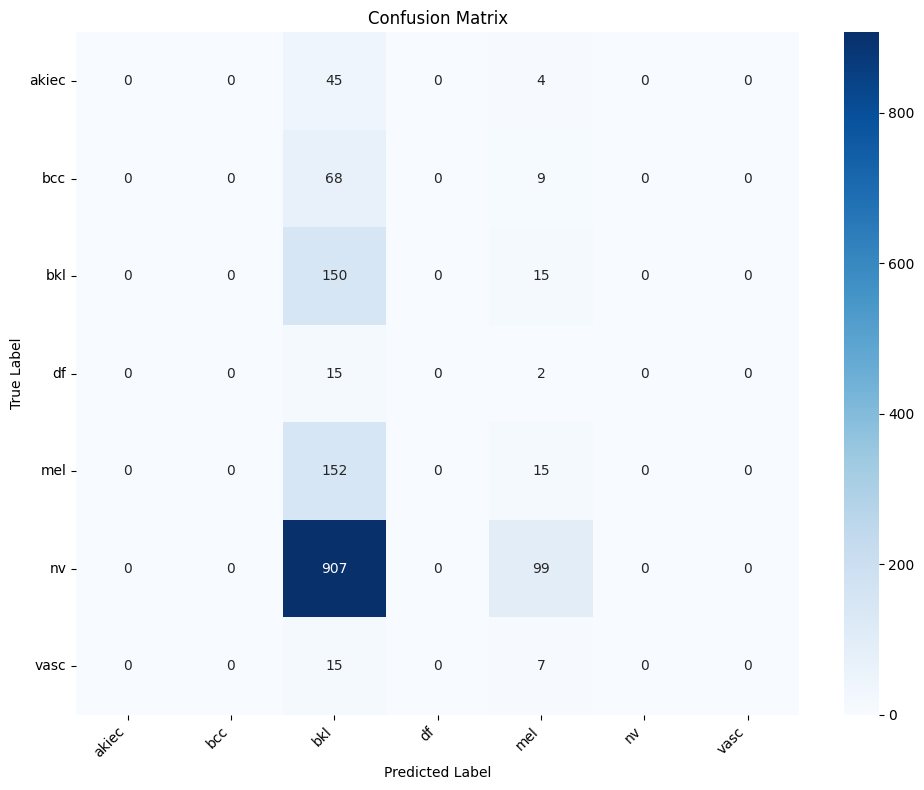

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


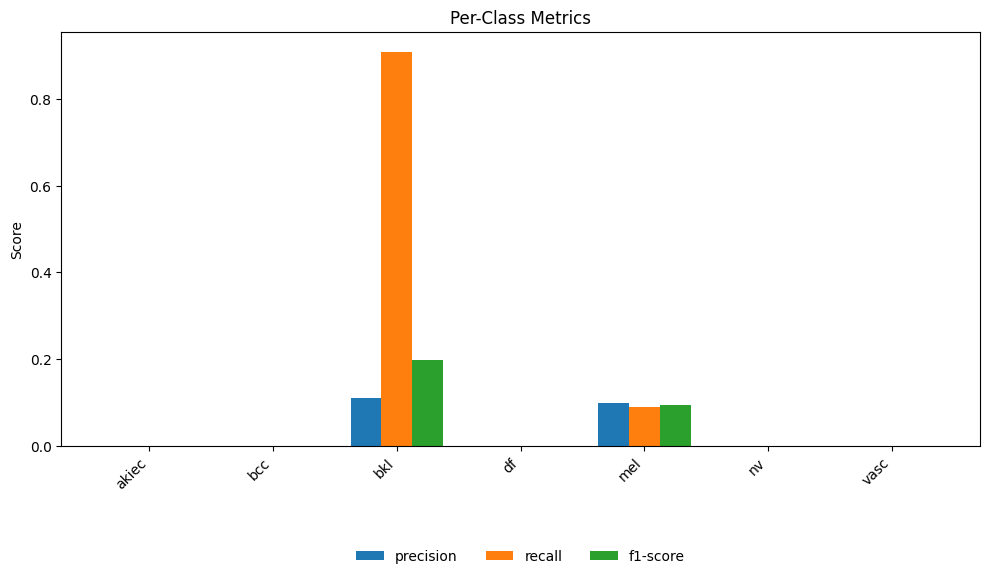

In [24]:
import seaborn as sns # Import seaborn
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plotting

model.eval()

all_preds = []
all_labels = []

# Define CFG if it's not defined elsewhere
# Assuming use_amp should be True/False based on the previous training setup
if 'CFG' not in locals() and 'CFG' not in globals():
    CFG = {"use_amp": True} # Or False, depending on your training configuration

# Evaluate on the test set to get all predictions and labels
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Evaluating Test Set", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.amp.autocast('cuda', enabled=CFG["use_amp"]):
            outputs = model(imgs)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Get class names
class_names = class_names # Use the globally defined class_names list

# Print Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Print Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
print(cm)

# Plot Confusion Matrix (optional)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Create df_report from classification_report output for plotting
report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# ==== Plot Metric Bars ====
metrics = ["precision", "recall", "f1-score"]
plt.figure(figsize=(10, 6))

x = np.arange(len(class_names))
width = 0.25

for i, m in enumerate(metrics):
    plt.bar(x + i * width, df_report.iloc[:-3][m], width=width, label=m)

plt.xticks(x + width, class_names, rotation=45, ha='right')
plt.ylabel("Score")
plt.title("Per-Class Metrics")

# --- Đưa legend ra ngoài hẳn, tụt xuống dưới ---
plt.legend(
    loc='upper center',        # căn giữa theo chiều ngang
    bbox_to_anchor=(0.5, -0.22),  # 0.5 là giữa trục x, -0.12 là khoảng cách tụt xuống
    ncol=3,                    # các nhãn nằm trên cùng 1 hàng
    frameon=False              # không có khung
)

plt.tight_layout()
plt.show()

In [21]:
# Optional paper-style protocol: use deep features + classical ML classifiers.\n
def extract_features(model, loader):
    model.eval()
    feats, labels = [], []
    with torch.no_grad():
        for images, y in loader:
            images = images.to(device)
            f = model.extract_feature_vector(images).cpu().numpy()
            feats.append(f)
            labels.append(y.numpy())
    return np.concatenate(feats, axis=0), np.concatenate(labels, axis=0)

X_train, y_train = extract_features(model, train_loader)
X_val, y_val = extract_features(model, val_loader)
X_test, y_test = extract_features(model, test_loader)

X_tr = np.concatenate([X_train, X_val], axis=0)
y_tr = np.concatenate([y_train, y_val], axis=0)

classical_models = {
    'SVM_RBF': SVC(kernel='rbf', C=5.0, gamma='scale', class_weight='balanced'),
    'KNN_7': KNeighborsClassifier(n_neighbors=7),
    'LogReg': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(max_depth=20, class_weight='balanced', random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(512, 256), learning_rate_init=1e-3, max_iter=80, random_state=42)
}

results = []
for name, clf in classical_models.items():
    print(f'\nTraining {name} ...')
    clf.fit(X_tr, y_tr)
    pred = clf.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results.append((name, acc))
    print(f'{name} test acc: {acc:.4f}')

results = sorted(results, key=lambda x: x[1], reverse=True)
print('\n=== Classical classifier ranking on deep features ===')
for name, acc in results:
    print(f'{name:15s} : {acc:.4f}')


Training SVM_RBF ...
SVM_RBF test acc: 0.7505

Training KNN_7 ...
KNN_7 test acc: 0.7199

Training LogReg ...
LogReg test acc: 0.6620

Training DecisionTree ...
DecisionTree test acc: 0.5542

Training MLP ...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (80) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP test acc: 0.8024

=== Classical classifier ranking on deep features ===
MLP             : 0.8024
SVM_RBF         : 0.7505
KNN_7           : 0.7199
LogReg          : 0.6620
DecisionTree    : 0.5542


In [ ]:
# Save weights
save_path = 'hybrid_convnext_swin_attention_best.pth'
torch.save(model.state_dict(), save_path)
print('Saved:', save_path)